In [21]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file and check the data dimension

In [22]:
pd_df = pd.read_csv("german_credit.csv").dropna()

In [23]:
pd_df.shape

(1000, 21)

In [24]:
pd_df.columns

Index(['default', 'account_check_status', 'duration_in_month',
       'credit_history', 'purpose', 'credit_amount', 'savings',
       'present_emp_since', 'installment_as_income_perc',
       'personal_status_sex', 'other_debtors', 'present_res_since', 'property',
       'age', 'other_installment_plans', 'housing', 'credits_this_bank', 'job',
       'people_under_maintenance', 'telephone', 'foreign_worker'],
      dtype='object')

In [25]:
pd_df.head(5)

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [26]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [27]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

X = pd_df.drop(['default'], axis=1)
y = pd_df[['default']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5 , random_state=5)

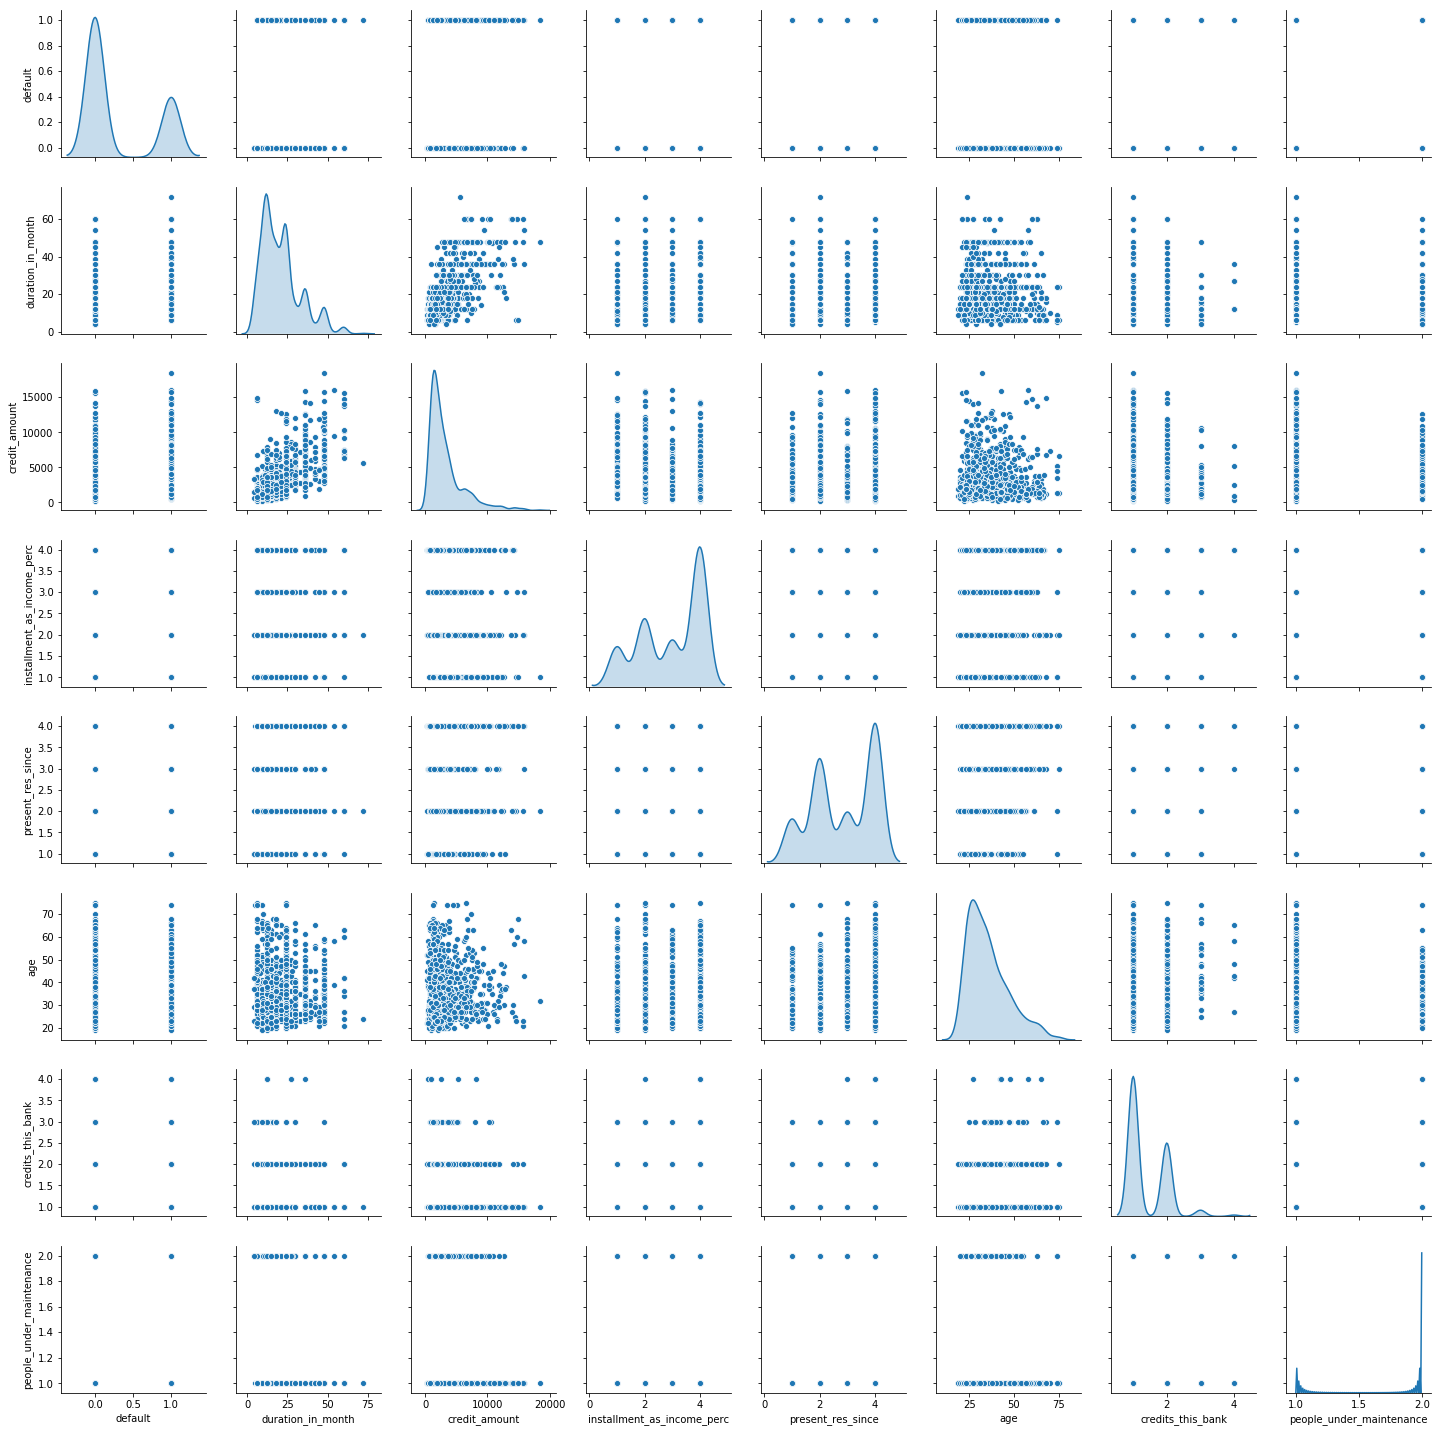

In [28]:
import seaborn as sns
sns.pairplot(pd_df, diag_kind='kde')

In [0]:
# Lets build a Ensemble model but need to modify the dataset first


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [29]:
# Print Shape of model data
pd_df = pd.get_dummies(pd_df, drop_first=True)
pd_df.shape

(1000, 49)

### Check for highly correlated variables but don't required any treatment for this use case

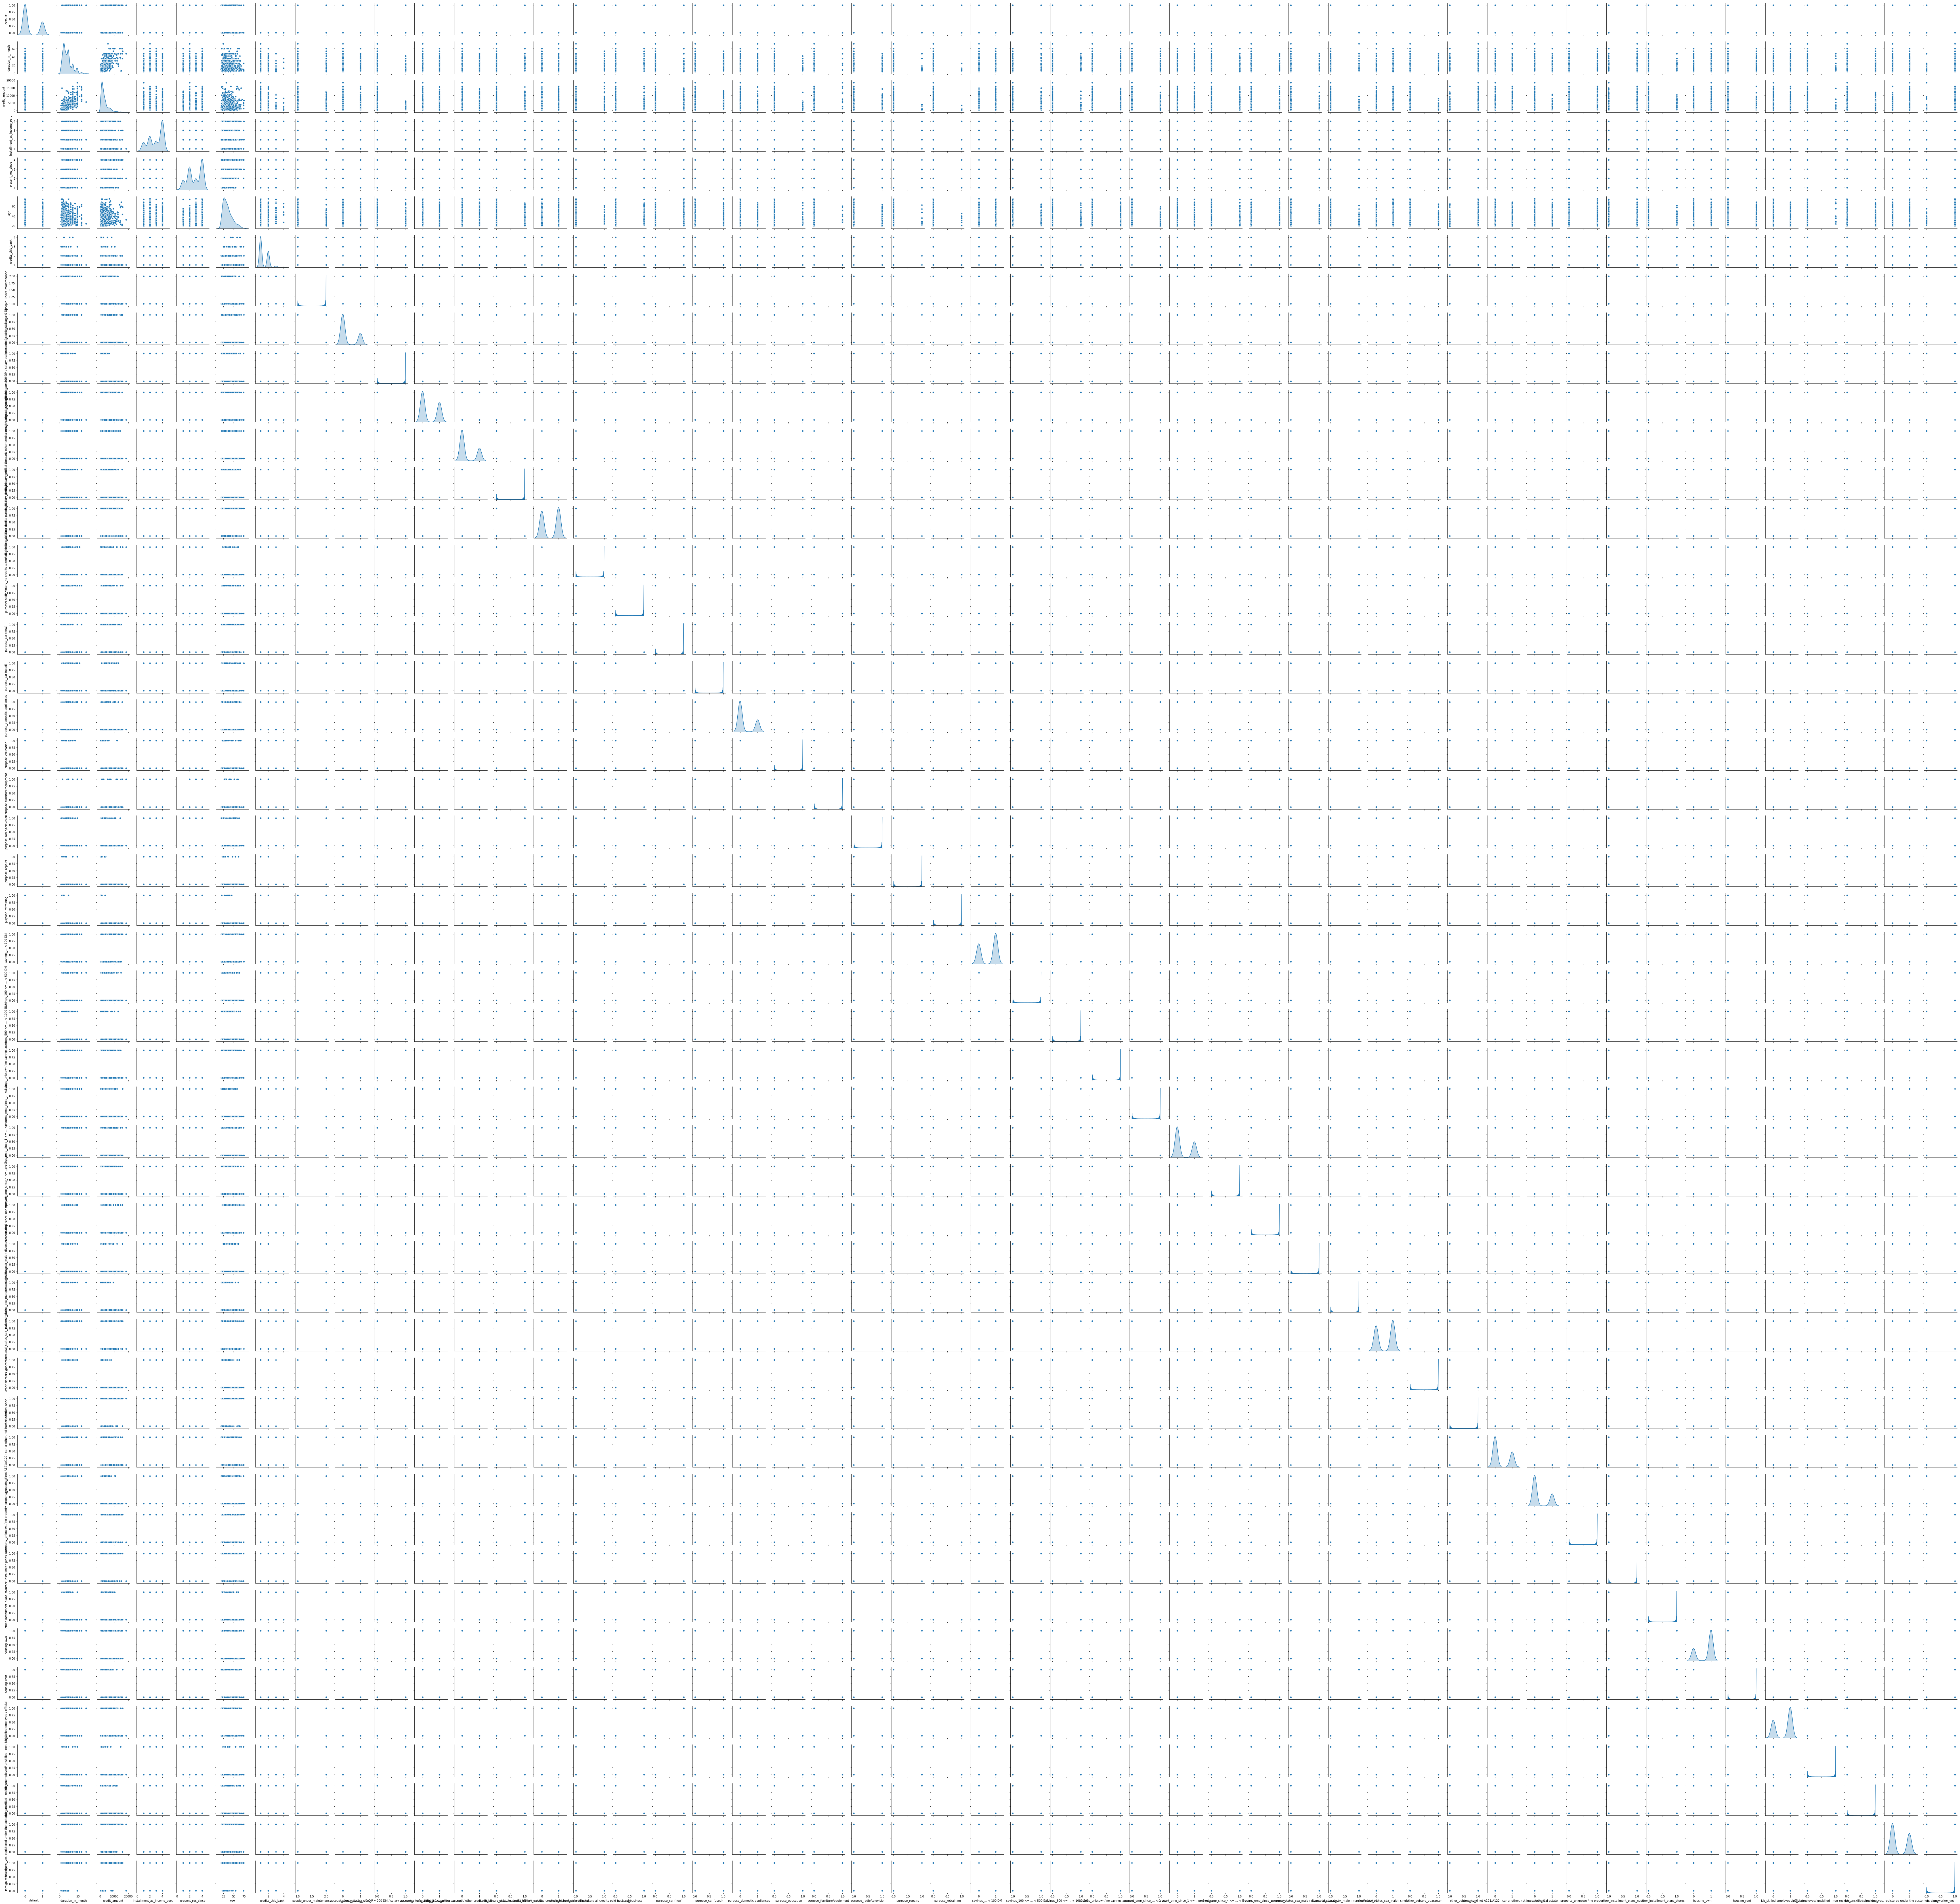

In [18]:
import seaborn as sns
sns.pairplot(pd_df, diag_kind='kde')

### Drop the original variables which are converted to dummy

In [0]:
print("No attributes can be dropped")

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [40]:
X = pd_df.drop(['default'], axis=1)
y = pd_df[['default']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3 , random_state=5)


### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [41]:
from sklearn.ensemble import RandomForestClassifier
Rf_model = RandomForestClassifier(n_estimators=500,criterion='entropy',random_state=9999,n_jobs=2 )

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [42]:
from sklearn.metrics import accuracy_score
Rf_model.fit(X_train, y_train)
y_predict = Rf_model.predict(X_test)
metrics.confusion_matrix(y_predict, y_test)

array([[198,  51],
       [ 20,  31]])

In [43]:
testAccuracy = accuracy_score(y_test, y_predict)
print(testAccuracy)

0.7633333333333333


### Q6 Show the list of the features importance( 1 Marks)

In [46]:
print("credit_history, credit_amount, personal_status_sex, property, age arethe important features of the data.")

 0.370800 (0.006073)


### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [0]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [47]:
# Use below values
num_folds = 10
seed = 77

results = []
scoring = 'recall'
kfold = model_selection.KFold(n_splits=10,random_state=77)
cv_results = model_selection.cross_val_score(Rf_model, X, y, cv=kfold, scoring=scoring)
results.append(cv_results)

msg = " %f (%f)" % ( np.mean(cv_results), cv_results.var())
print(msg)

 0.406916 (0.017196)


In [0]:
#Validate the Random Forest model build above using k fold

In [0]:
#Calculate Mean score

In [48]:
 np.mean(cv_results)

0.40691635867606263

In [0]:
# Calculate score standard deviation using std()

In [49]:
cv_results.std()

0.1311345225562227

# Q8 Print the confusion matrix( 1 Marks)

In [51]:
from sklearn.metrics import accuracy_score
Rf_model.fit(X_train, y_train)
y_predict = Rf_model.predict(X_test)
metrics.confusion_matrix(y_predict, y_test)

array([[198,  51],
       [ 20,  31]])

# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [55]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc

testPreds = Rf_model.predict(X_test)
testAccuracy = accuracy_score(y_test, testPreds)
testRecall = recall_score(y_test, testPreds)
testPrecision = precision_score(y_test, testPreds)
testF1score = f1_score(y_test, testPreds)
print("testAccuracy:", +(testAccuracy))
print("testRecall:", +(testRecall))
print("testPrecision:", +(testPrecision))
print("testF1score:", +(testF1score))

testAccuracy: 0.7633333333333333
testRecall: 0.3780487804878049
testPrecision: 0.6078431372549019
testF1score: 0.46616541353383456


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [56]:
#Hint: Use roc_curve
from sklearn.metrics import roc_curve, auc
y_predictProb = Rf_model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_predictProb[::,1])
roc_auc = auc(fpr, tpr)
roc_auc

0.7565171179234728

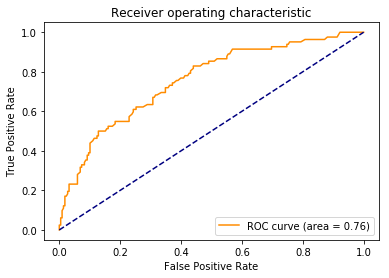

In [57]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

In [58]:
roc_auc = auc(fpr, tpr)
roc_auc

0.7565171179234728

### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [0]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [0]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    rfm.fit(X_, y_)
    y_pred = rfm.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [0]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.6893333333333334
Standard deviation:  0.014966629547095768
